# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [3]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [4]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    # Перший шар, який складається з 128 нейронів
    # Місце для вашого коду
    self.first_layer = DenseLayer(in_features=num_features,out_features=n_hidden_1)

    # Другий шар, який складається з 256 нейронів
    # Місце для вашого коду
    self.second_layer = DenseLayer(in_features=n_hidden_1,out_features=n_hidden_2)
    # Вихідний шар
    # Місце для вашого коду
    self.output_layer = DenseLayer(in_features=n_hidden_2,out_features=num_classes)


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.first_layer(x)

    x = self.second_layer(x)

    x = self.output_layer(x,activation=1)

    return x

In [5]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
  ## first option

  # accuracy = K.metrics.CategoricalAccuracy()
  # accuracy.update_state(y_true,y_pred)
  # result = accuracy.result()
  # return result

  ## second option

  # identify the highest propability
  y_pred = tf.argmax(y_pred,axis=1)
  y_pred = tf.cast(y_pred, tf.uint8)

  comparison = tf.equal(y_true,y_pred)

  convert_to_binary = tf.cast(comparison, tf.float32)

  result = tf.reduce_mean(convert_to_binary)

  return result

In [6]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
    optimizer = tf.optimizers.SGD(learning_rate)

    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)

    grads = g.gradient(loss, neural_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, neural_net.trainable_variables))

    return loss

In [7]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    loss = train(neural_net,batch_x,batch_y)


    if step % display_step == 0:
        pred = neural_net(batch_x)
        # Місце для вашого коду
        acc = accuracy(pred,batch_y)
        accuracy_history.append(acc.numpy())
        loss_history.append(loss.numpy())


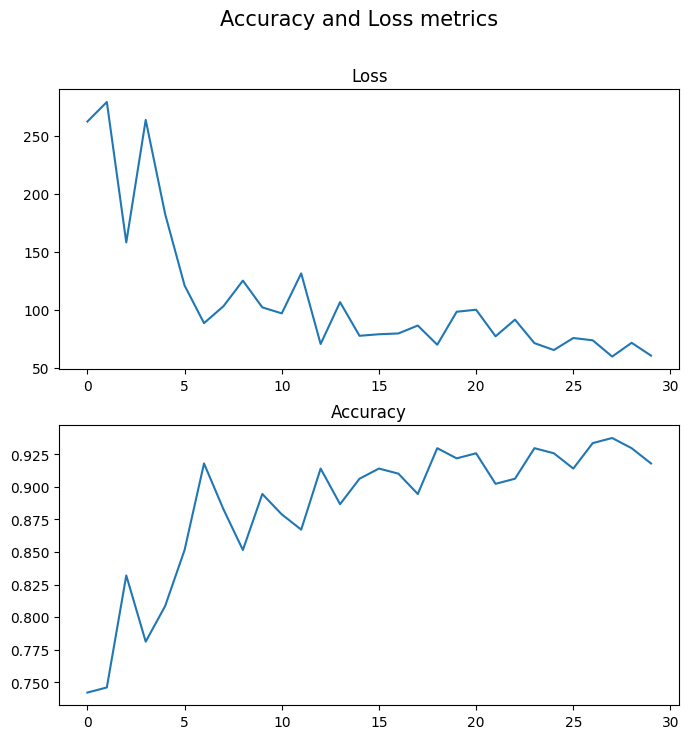

In [8]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

# Виведіть графік функції втрат
# Місце для вашого коду
fig, axs = plt.subplots(2,1,figsize=(8,8))
axs[0].plot(loss_history)
axs[0].set_title('Loss')
# Виведіть графік точності
# Місце для вашого коду
axs[1].plot(accuracy_history)
axs[1].set_title('Accuracy')
fig.suptitle('Accuracy and Loss metrics', fontsize=15)

plt.show()

In [9]:
# Обчисліть точність навченої нейромережі
test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_data = test_data.batch(batch_size).prefetch(1)
test_accuracy = []

# Тестування моделі на тестових даних
for x_batch, y_batch in test_data:
  pred = neural_net(x_batch)
  test_accuracy.append(accuracy(pred,y_batch).numpy())

print('середня точність: ', np.mean(test_accuracy))


середня точність:  0.9057617


In [20]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Місце для вашого коду

if "overall_results" not in globals():
    overall_results = {}
if 'accuracy_dict' not in globals():
    accuracy_dict = {}

run_number = len(overall_results) + 1
overall_results[f"run_{run_number}"] = {}
accuracy_dict[f"run_{run_number}"] = {}

IMAGES_AMOUNT = 10
indices = np.random.choice(len(x_test),IMAGES_AMOUNT,replace=False)
images = x_test[indices]
labels = y_test[indices]

pred = neural_net(images)
predictions = tf.argmax(pred,axis=1)

correct_results = 0

for i in range(IMAGES_AMOUNT):
    print(f"True: {labels[i]}, Predicted: {predictions[i].numpy()}")

    if labels[i] == predictions[i].numpy():
      correct_results +=1

    overall_results[f'run_{run_number}'][f'check_{i+1}'] = {f'label_{i}': int(labels[i]), f'prediction_{i}': int(predictions[i].numpy())}
accuracy = correct_results / IMAGES_AMOUNT
accuracy_dict[f'run_{run_number}'] = accuracy
print(f'Accuracy of the run_{run_number}: ', accuracy)

True: 3, Predicted: 3
True: 6, Predicted: 6
True: 8, Predicted: 8
True: 3, Predicted: 3
True: 1, Predicted: 1
True: 4, Predicted: 6
True: 5, Predicted: 3
True: 7, Predicted: 7
True: 9, Predicted: 9
True: 6, Predicted: 6
Accuracy of the run_10:  0.8


In [21]:
overall_results

{'run_1': {'check_1': {'label_0': 4, 'prediction_0': 4},
  'check_2': {'label_1': 4, 'prediction_1': 4},
  'check_3': {'label_2': 1, 'prediction_2': 1},
  'check_4': {'label_3': 8, 'prediction_3': 8},
  'check_5': {'label_4': 4, 'prediction_4': 4},
  'check_6': {'label_5': 3, 'prediction_5': 6},
  'check_7': {'label_6': 9, 'prediction_6': 9},
  'check_8': {'label_7': 1, 'prediction_7': 1},
  'check_9': {'label_8': 0, 'prediction_8': 0},
  'check_10': {'label_9': 8, 'prediction_9': 8}},
 'run_2': {'check_1': {'label_0': 7, 'prediction_0': 7},
  'check_2': {'label_1': 2, 'prediction_1': 3},
  'check_3': {'label_2': 2, 'prediction_2': 2},
  'check_4': {'label_3': 9, 'prediction_3': 9},
  'check_5': {'label_4': 0, 'prediction_4': 0},
  'check_6': {'label_5': 3, 'prediction_5': 3},
  'check_7': {'label_6': 5, 'prediction_6': 5},
  'check_8': {'label_7': 3, 'prediction_7': 3},
  'check_9': {'label_8': 2, 'prediction_8': 2},
  'check_10': {'label_9': 3, 'prediction_9': 3}},
 'run_3': {'check_

In [29]:
accuracy_dict

{'run_1': 0.9,
 'run_2': 0.9,
 'run_3': 0.8,
 'run_4': 1.0,
 'run_5': 0.9,
 'run_6': 0.9,
 'run_7': 0.9,
 'run_8': 0.7,
 'run_9': 1.0,
 'run_10': 0.8}

In [27]:
from sklearn.metrics import classification_report

pred = neural_net(x_test)
y_pred = tf.argmax(pred, axis=1).numpy()

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       980
           1       0.97      0.98      0.97      1135
           2       0.91      0.88      0.89      1032
           3       0.85      0.88      0.87      1010
           4       0.91      0.91      0.91       982
           5       0.86      0.85      0.86       892
           6       0.90      0.94      0.92       958
           7       0.92      0.90      0.91      1028
           8       0.87      0.86      0.86       974
           9       0.88      0.88      0.88      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



висновки: Було успішно побудовано та навчено нейронну мережу для класифікації цифр MNIST. Модель досягла 90% точності на тестовій вибірці, а значення precision, recall і F1-score для всіх класів залишаються високими (0.85–0.97), що свідчить про стабільну якість класифікації. Перевірка на 10 випадкових зображеннях показала точність від 70% до 100%, що є очікуваним через випадковий вибір невеликої кількості прикладів.
